# JJ connected current-current correlator -- analysis (tp projection)

Mimics `meson_wall_various_ell_nu1tuning_claude_v2.ipynb` for the conserved-current $G(t)$
produced by `jj_conn_tpproj_claude.cu`.  Files: `data_<ESNID>/tp_<current>/conn.<k>.<h>.h5`
with datasets `Vpp/{real,imag}`, `Vmm/{real,imag}` (length $N_t$).  Here a 'sample' = one
`conn.*.*.h5` file (= a hit for free-field / a config for an ensemble); jackknife over them.

In [1]:
import h5py
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

import glob

from natsort import natsorted

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins
        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins - 1

    def mean( self ): return self.est
    def var( self ):  return self.var_est
    def err( self ):  return np.sqrt(self.var_est)

# resampling estimators (data shape = (nsamples, Nt))
def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def jack_avg(i, binsize, np_data):
    return np_data[i]

def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1) >= err > 10**(-i):
            tmp = err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1) >= err > 10**(-i):
            tmp = err*10**(i+1)
            return ('{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'
                    +': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma')

In [3]:
# ---- parameters (match the run / CLI) ----
gsq = "8.000000"
at  = "0.200000"
Nt  = 128
L   = 1
Nf  = 2
nu0 = "1.000000"

current = "vector"   # tp_<current>
binsize = 1

dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'

In [4]:
# ---- .h5 completeness check (full dataset set + length Nt) ----
# A run interrupted mid-write leaves a file missing datasets (HighFive writes them one at a time),
# so a "complete" file must contain EVERY expected key and each must have length Nt.
VKEYS = ['Vpp/real', 'Vpp/imag', 'Vmm/real', 'Vmm/imag']   # vector tp file: full dataset set
AKEYS = ['Apm/real', 'Apm/imag']                            # axial  tp file: full dataset set

def h5_complete(fn, keys, length=None):
    '''True iff fn opens and contains all dataset paths in `keys`, each of the given length.'''
    try:
        with h5py.File(fn, 'r') as f:
            for k in keys:
                if k not in f:
                    return False
                if length is not None and f[k].shape[0] != length:
                    return False
    except (OSError, KeyError):
        return False
    return True

In [20]:
# ---- jackknife helper + SIGNED log-axis plotters (no abs) ----
def jk_of(arr):
    jk = Jackknife(arr.shape[0], binsize)
    jk.set(simple_mean, arr)
    jk.do_it()
    return jk

# Shared y-range for all signed correlator plots (tune to taste).
YLIM = (1e-11, 1e-1)

# On a log axis a signed quantity is shown by drawing BOTH +y and -y; matplotlib drops the
# non-positive branch, so whichever sign is positive is the one visible.  The + and - branches
# get DISTINCT colors (cp / cm).
def plot_pm(ax, x, y, label, cp='C0', cm='C3'):
    ax.plot(x,  y, ls='solid', color=cp, label='+' + label)
    ax.plot(x, -y, ls='--',    color=cm, label='-' + label)

def ebar_pm(ax, x, y, e, label, cp='C0', cm='C3'):
    ax.errorbar(x,  y, e, ls='solid', capsize=2.0, color=cp, label='+' + label)
    ax.errorbar(x, -y, e, ls='--',    capsize=2.0, color=cm, label='-' + label)

In [21]:
# ---- ESNID + loader.  esnid mirrors jj_conn_tpproj_claude.cu:
#   esnid = (free?'free':<ens_basename>) + '_vmRe'+to_string(mre)+'vmIm'+to_string(mim)
#   (std::to_string -> 6 decimals).  ens='free' for the free-field run.
def esnid(mre, mim, ens='free'):
    return ens + '_vmRe' + '%.6f' % mre + 'vmIm' + '%.6f' % mim

def conn_dir(mre, mim, ens='free'):
    return dir1 + 'data_' + esnid(mre, mim, ens) + '/tp_' + current + '/'

def load(mre, mim, ens='free', channel='Vpp', part='real', keys=VKEYS):
    '''Return array (nsamples, Nt): one row per COMPLETE conn.*.*.h5 (full key set + length Nt).
       Incomplete files (interrupted writes) are skipped and reported.  The full-key check is
       file-level, so every (channel, part) call keeps the SAME files -> Vpp/Vmm stay aligned.'''
    path  = conn_dir(mre, mim, ens)
    files = natsorted(glob.glob(path + 'conn.*.*.h5'))
    data, bad = [], []
    for fn in files:
        if not h5_complete(fn, keys, Nt):
            bad.append(os.path.basename(fn)); continue
        with h5py.File(fn, 'r') as f:
            data.append( f[channel + '/' + part][:] )
    if bad:
        print('  [load] skipped %d incomplete file(s) in %s: %s' % (len(bad), path, bad))
    return np.array(data)

xxx = float(at) * np.arange(Nt)

In [22]:
# ---- valence masses to compare (mre = m_F real, mim = m_P imaginary) ----
masses = [ (0.0, 0.0), (0.1, 0.0), (0.0, 0.1) ]   # massless, m_F, m_P
# masses = [ (m, 0.0) for m in [0.01,0.05,0.1,0.2] ]   # m_F sweep
# masses = [ (0.0, m) for m in [0.01,0.05,0.1,0.2] ]   # m_P sweep

# Re and Im kept separately (shape (nsamples, Nt)) so the SIGN is preserved for the plots below.
vppR = {}; vppI = {}
vmmR = {}; vmmI = {}
for (mre, mim) in masses:
    vppR[(mre,mim)] = load(mre, mim, channel='Vpp', part='real')
    vppI[(mre,mim)] = load(mre, mim, channel='Vpp', part='imag')
    vmmR[(mre,mim)] = load(mre, mim, channel='Vmm', part='real')
    vmmI[(mre,mim)] = load(mre, mim, channel='Vmm', part='imag')
    print(mre, mim, '  nsamples x Nt =', vppR[(mre,mim)].shape)

0.0 0.0   nsamples x Nt = (60, 128)
0.1 0.0   nsamples x Nt = (16, 128)
0.0 0.1   nsamples x Nt = (16, 128)


### Sign check (no `abs`)

Plots show the **signed** correlator on a log axis by drawing both $+G$ (solid) and $-G$ (dashed);
whichever sign is positive is the visible branch.  CFT prediction for the conserved vector current
(PDF Sec. 4.3): the **temporal** projection computed here is **negative**,
$$
G_t(t) = -C_J\,e^{-\Delta t}(1-e^{-t})^{-2\Delta},\qquad \Delta = D-1 = 2
$$
(Eq. 4.31), so $\mathrm{Re}\,G_{++}(t)<0$ and the **dashed ($-$) branch should be the visible one**.
The spatial projection $G_s = +C_j(D-1)e^{-\Delta t}(1-e^{-t})^{-2\Delta}>0$ (Eq. 4.28) is the
opposite sign -- a cross-check once `spproj` exists.  Imaginary parts $\approx 0$ for massless /
$m_F$; a nonzero Im is the parity-breaking signal ($m_P$).

In [23]:
# ---- (commented: no-errorbar mean overview; the per-mass errorbar cells below are the ones used) ----
# fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# for (mre, mim) in masses:
#     lbl = 'm=(%.2f,%.2f)' % (mre, mim)
#     plot_pm(ax[0], xxx, np.mean(vppR[(mre,mim)], axis=0), lbl)
#     plot_pm(ax[1], xxx, np.mean(vppI[(mre,mim)], axis=0), lbl)
# for a, lab in zip(ax, ['Re $G_{++}$', 'Im $G_{++}$']):
#     a.set_yscale('log'); a.set_xlabel('$t$ (a.u.)'); a.set_ylabel('|' + lab + '|')
#     a.set_title(lab + '   (+ solid, - dashed)'); a.legend(fontsize=8)
# plt.tight_layout()

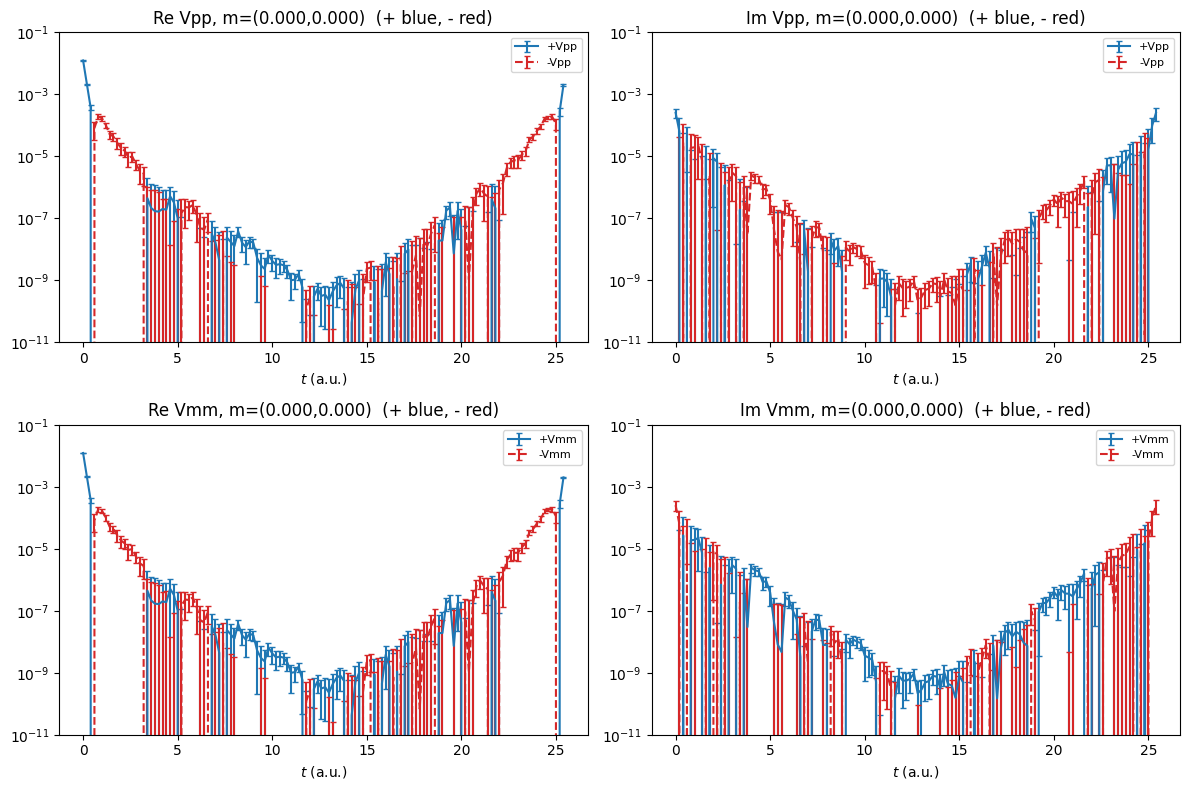

In [24]:
# ---- jackknife, SIGNED Re/Im for ONE mass; Vpp and Vmm on SEPARATE rows (no abs).  Expect Re < 0. ----
mre, mim = masses[0]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
jkR_pp = jk_of(vppR[(mre,mim)]); jkI_pp = jk_of(vppI[(mre,mim)])
jkR_mm = jk_of(vmmR[(mre,mim)]); jkI_mm = jk_of(vmmI[(mre,mim)])
ebar_pm(ax[0][0], xxx, jkR_pp.mean(), jkR_pp.err(), 'Vpp')
ebar_pm(ax[0][1], xxx, jkI_pp.mean(), jkI_pp.err(), 'Vpp')
ebar_pm(ax[1][0], xxx, jkR_mm.mean(), jkR_mm.err(), 'Vmm')
ebar_pm(ax[1][1], xxx, jkI_mm.mean(), jkI_mm.err(), 'Vmm')
titles = [['Re Vpp', 'Im Vpp'], ['Re Vmm', 'Im Vmm']]
for i in range(2):
    for j in range(2):
        ax[i][j].set_yscale('log'); ax[i][j].set_ylim(YLIM); ax[i][j].set_xlabel('$t$ (a.u.)')
        ax[i][j].set_title('%s, m=(%.3f,%.3f)  (+ blue, - red)' % (titles[i][j], mre, mim))
        ax[i][j].legend(fontsize=8)
plt.tight_layout()

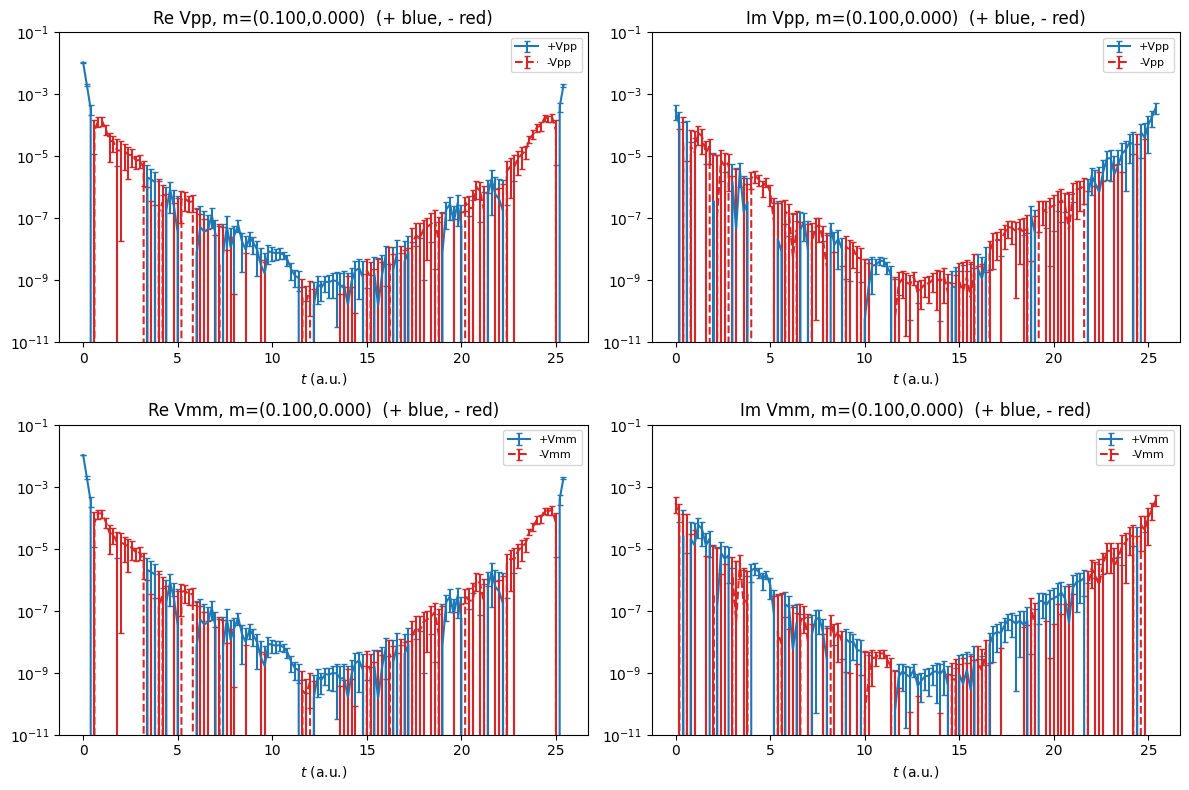

In [25]:
# ---- jackknife, SIGNED Re/Im for ONE mass; Vpp and Vmm on SEPARATE rows (no abs).  Expect Re < 0. ----
mre, mim = masses[1]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
jkR_pp = jk_of(vppR[(mre,mim)]); jkI_pp = jk_of(vppI[(mre,mim)])
jkR_mm = jk_of(vmmR[(mre,mim)]); jkI_mm = jk_of(vmmI[(mre,mim)])
ebar_pm(ax[0][0], xxx, jkR_pp.mean(), jkR_pp.err(), 'Vpp')
ebar_pm(ax[0][1], xxx, jkI_pp.mean(), jkI_pp.err(), 'Vpp')
ebar_pm(ax[1][0], xxx, jkR_mm.mean(), jkR_mm.err(), 'Vmm')
ebar_pm(ax[1][1], xxx, jkI_mm.mean(), jkI_mm.err(), 'Vmm')
titles = [['Re Vpp', 'Im Vpp'], ['Re Vmm', 'Im Vmm']]
for i in range(2):
    for j in range(2):
        ax[i][j].set_yscale('log'); ax[i][j].set_ylim(YLIM); ax[i][j].set_xlabel('$t$ (a.u.)')
        ax[i][j].set_title('%s, m=(%.3f,%.3f)  (+ blue, - red)' % (titles[i][j], mre, mim))
        ax[i][j].legend(fontsize=8)
plt.tight_layout()

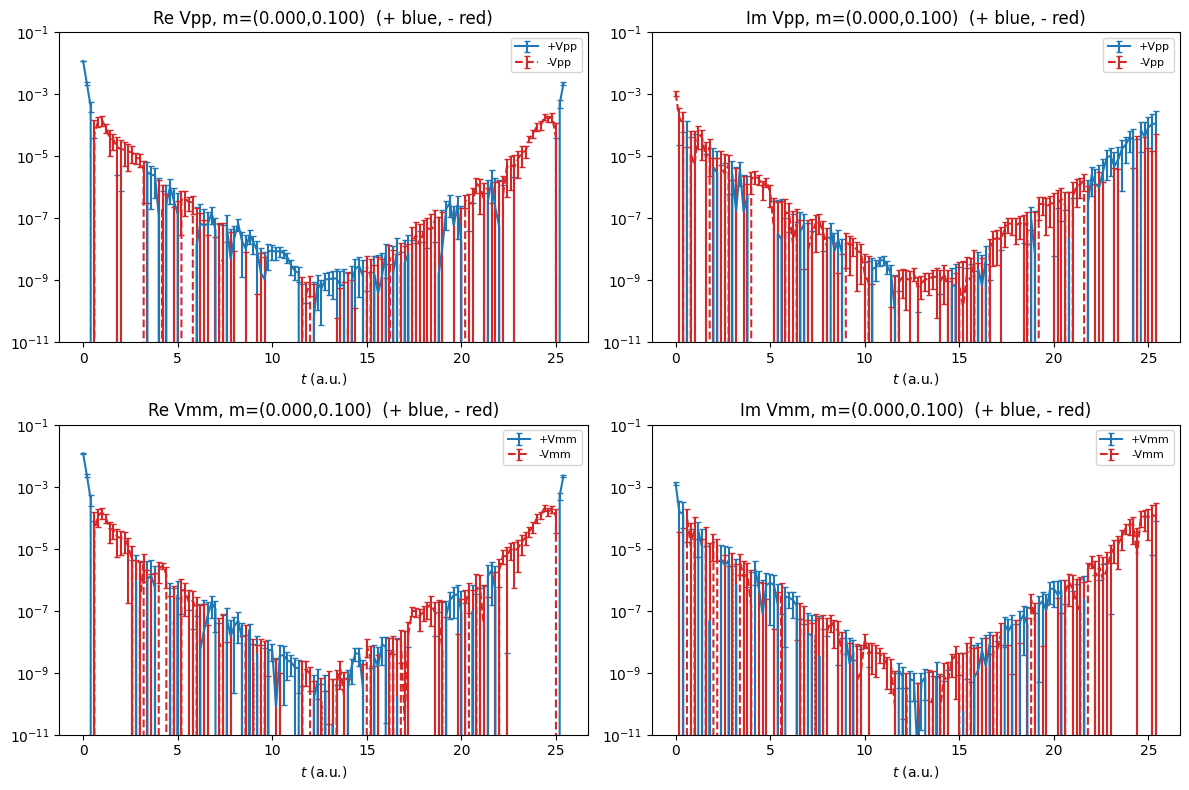

In [26]:
# ---- jackknife, SIGNED Re/Im for ONE mass; Vpp and Vmm on SEPARATE rows (no abs).  m_P: Im is the parity signal. ----
mre, mim = masses[2]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
jkR_pp = jk_of(vppR[(mre,mim)]); jkI_pp = jk_of(vppI[(mre,mim)])
jkR_mm = jk_of(vmmR[(mre,mim)]); jkI_mm = jk_of(vmmI[(mre,mim)])
ebar_pm(ax[0][0], xxx, jkR_pp.mean(), jkR_pp.err(), 'Vpp')
ebar_pm(ax[0][1], xxx, jkI_pp.mean(), jkI_pp.err(), 'Vpp')
ebar_pm(ax[1][0], xxx, jkR_mm.mean(), jkR_mm.err(), 'Vmm')
ebar_pm(ax[1][1], xxx, jkI_mm.mean(), jkI_mm.err(), 'Vmm')
titles = [['Re Vpp', 'Im Vpp'], ['Re Vmm', 'Im Vmm']]
for i in range(2):
    for j in range(2):
        ax[i][j].set_yscale('log'); ax[i][j].set_ylim(YLIM); ax[i][j].set_xlabel('$t$ (a.u.)')
        ax[i][j].set_title('%s, m=(%.3f,%.3f)  (+ blue, - red)' % (titles[i][j], mre, mim))
        ax[i][j].legend(fontsize=8)
plt.tight_layout()

max |Vmm - conj(Vpp)| = 0.0


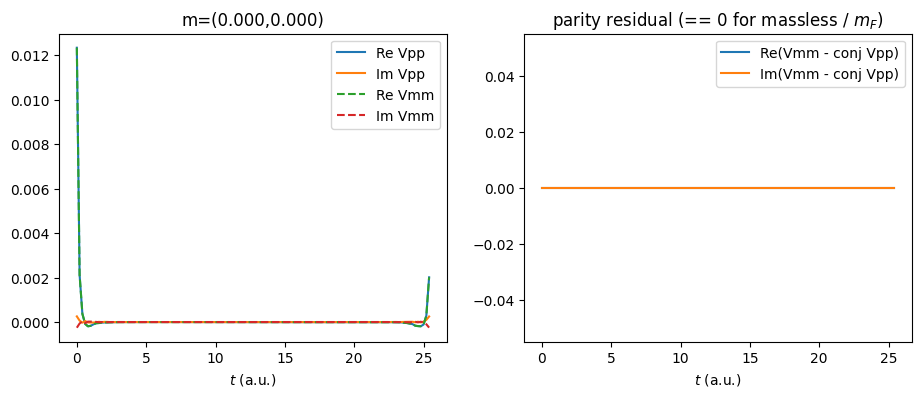

In [27]:
# ---- Im part + parity cross-check ----
# Non-parity (massless / m_F): the program writes Vmm = conj(Vpp) (mmRe=ppRe, mmIm=-ppIm),
#   so Vmm - conj(Vpp) == 0 to machine precision -- a write / round-trip sanity check.
# Parity (m_P): Vmm is computed INDEPENDENTLY via tilde D_{m_P}, so Vmm - conj(Vpp) is the
#   genuine parity-breaking signal (nonzero).
mre, mim = masses[0]
ppR = np.mean(load(mre, mim, channel='Vpp', part='real'), axis=0)
ppI = np.mean(load(mre, mim, channel='Vpp', part='imag'), axis=0)
mmR = np.mean(load(mre, mim, channel='Vmm', part='real'), axis=0)
mmI = np.mean(load(mre, mim, channel='Vmm', part='imag'), axis=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# left: Re/Im of both channels
ax[0].plot(xxx, ppR,       label='Re Vpp')
ax[0].plot(xxx, ppI,       label='Im Vpp')
ax[0].plot(xxx, mmR, '--', label='Re Vmm')
ax[0].plot(xxx, mmI, '--', label='Im Vmm')
ax[0].set_xlabel('$t$ (a.u.)'); ax[0].set_title('m=(%.3f,%.3f)' % (mre, mim)); ax[0].legend()

# right: parity residual  Vmm - conj(Vpp) = (mmR - ppR) + i (mmI + ppI)
resR = mmR - ppR
resI = mmI + ppI
ax[1].plot(xxx, resR, label='Re(Vmm - conj Vpp)')
ax[1].plot(xxx, resI, label='Im(Vmm - conj Vpp)')
ax[1].set_xlabel('$t$ (a.u.)')
ax[1].set_title('parity residual (== 0 for massless / $m_F$)'); ax[1].legend()

print('max |Vmm - conj(Vpp)| =', np.max(np.abs(resR + 1j*resI)))

/tmp/ipykernel_3694670/2171426816.py:7: RuntimeWarning: invalid value encountered in arccosh
  tmp = np.arccosh( avg / cor[int(Nt/2)] )   # ratio of like-signed values > 0, so Re G < 0 is fine


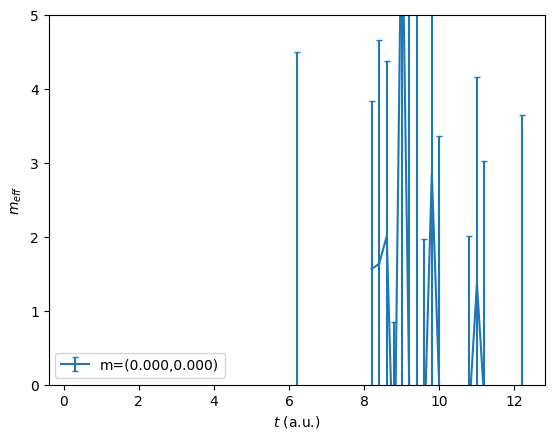

In [28]:
# ---- effective mass from Re G_{++}(t) (cosh/periodic), jackknifed.  Sign cancels in the ratio. ----
mre, mim = masses[0]
jkR = jk_of(vppR[(mre,mim)])

def meff( cor ):
    avg = (cor[1:int(Nt/2)] + np.flip(cor[int(Nt/2)+1:])) / 2
    tmp = np.arccosh( avg / cor[int(Nt/2)] )   # ratio of like-signed values > 0, so Re G < 0 is fine
    return (-tmp[1:] + tmp[:-1]) / float(at)

xx = np.arange(1, int(Nt/2)-1) * float(at)

jk_M = [ meff(s) for s in jkR.jack_avg ]
jk_meff = Jackknife( len(jk_M), 1 )
jk_meff.set( jack_avg, jk_M )
jk_meff.do_it()

plt.errorbar( xx, jk_meff.mean(), jk_meff.err(), capsize=2.0, label='m=(%.3f,%.3f)' % (mre,mim) )
plt.ylim(0.0, 5.0)
plt.xlabel('$t$ (a.u.)'); plt.ylabel('$m_{eff}$'); plt.legend()

## Axial connected correlator $C_{A+-}$

Loads `data_<ESNID>/tp_axial/conn.*.*.h5` (dataset `Apm/{real,imag}`, length $N_t$) produced by
`jj_conn_tpproj_axial_claude.cu`.  Single complex channel $C_{A+-}(t)$ -- only the $+-$ ordering is
computed; $C_{A-+}(\Delta t)=C_{A+-}(N_t-\Delta t)$ by reflection downstream (Eq. 3.57).  Valence:
massless / $m_F$ use the massless $D_\text{ov}$ on **both** legs (no conserved axial current at
$m_F\neq0$ -> massless-limit expression); $m_P$ uses $\tilde D_{m_P}$ on the sink leg.

In [14]:
# ---- axial loader (tp_axial, dataset Apm/{real,imag}) ----
def conn_dir_ax(mre, mim, ens='free'):
    return dir1 + 'data_' + esnid(mre, mim, ens) + '/tp_axial/'

def load_ax(mre, mim, ens='free', part='real', keys=AKEYS):
    '''Return array (nsamples, Nt): one row per COMPLETE conn.*.*.h5 in tp_axial.
       Incomplete files (interrupted writes) are skipped and reported.'''
    path  = conn_dir_ax(mre, mim, ens)
    files = natsorted(glob.glob(path + 'conn.*.*.h5'))
    data, bad = [], []
    for fn in files:
        if not h5_complete(fn, keys, Nt):
            bad.append(os.path.basename(fn)); continue
        with h5py.File(fn, 'r') as f:
            data.append( f['Apm/' + part][:] )
    if bad:
        print('  [load_ax] skipped %d incomplete file(s) in %s: %s' % (len(bad), path, bad))
    return np.array(data)

In [15]:
# ---- load axial C_{A+-} for the same masses ----
apmR = {}   # apmR[(mre,mim)] = (nsamples, Nt) real part of Apm
apmI = {}
for (mre, mim) in masses:
    apmR[(mre,mim)] = load_ax(mre, mim, part='real')
    apmI[(mre,mim)] = load_ax(mre, mim, part='imag')
    print(mre, mim, '  axial nsamples x Nt =', apmR[(mre,mim)].shape)

0.0 0.0   axial nsamples x Nt = (6, 128)
0.1 0.0   axial nsamples x Nt = (1, 128)
0.0 0.1   axial nsamples x Nt = (1, 128)


In [16]:
# ---- (commented: no-errorbar axial mean overview; the per-mass errorbar cell below is the one used) ----
# fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# for (mre, mim) in masses:
#     lbl = 'm=(%.2f,%.2f)' % (mre, mim)
#     plot_pm(ax[0], xxx, np.mean(apmR[(mre,mim)], axis=0), lbl)
#     plot_pm(ax[1], xxx, np.mean(apmI[(mre,mim)], axis=0), lbl)
# for a, lab in zip(ax, [r'Re $C_{A+-}$', r'Im $C_{A+-}$']):
#     a.set_yscale('log'); a.set_xlabel('$t$ (a.u.)'); a.set_ylabel('|' + lab + '|')
#     a.set_title(lab + '   (+ solid, - dashed)'); a.legend(fontsize=8)
# plt.tight_layout()

In [ ]:
# ---- jackknife, SIGNED Re/Im of C_{A+-} for each mass (no abs; rows = Re, Im) ----
fig, ax = plt.subplots(2, len(masses), figsize=(5*len(masses), 8), squeeze=False)
for j, (mre, mim) in enumerate(masses):
    jkR = jk_of(apmR[(mre,mim)]); jkI = jk_of(apmI[(mre,mim)])
    ebar_pm(ax[0][j], xxx, jkR.mean(), jkR.err(), 'Re')
    ebar_pm(ax[1][j], xxx, jkI.mean(), jkI.err(), 'Im')
    for i, lab in enumerate(['Re', 'Im']):
        ax[i][j].set_yscale('log'); ax[i][j].set_ylim(YLIM); ax[i][j].set_xlabel('$t$ (a.u.)')
        ax[i][j].set_title('%s $C_{A+-}$, m=(%.3f,%.3f)  (+ blue, - red)' % (lab, mre, mim))
        ax[i][j].legend(fontsize=8)
plt.tight_layout()

In [18]:
# ---- (commented: no-errorbar vector-vs-axial overview) ----
# mre, mim = masses[0]
# fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plot_pm(ax, xxx, np.mean(vppR[(mre,mim)], axis=0), r'vector Re $G_{++}$')
# plot_pm(ax, xxx, np.mean(apmR[(mre,mim)], axis=0), r'axial Re $C_{A+-}$')
# ax.set_yscale('log'); ax.set_xlabel('$t$ (a.u.)'); ax.set_ylabel('|Re|')
# ax.set_title('vector vs axial, m=(%.3f,%.3f)   (+ solid, - dashed)' % (mre, mim)); ax.legend(fontsize=8)

In [19]:
# ---- completeness audit: per mass, how many conn.*.*.h5 have the full key set ----
def audit(mre, mim, keys, subdir, ens='free'):
    path  = dir1 + 'data_' + esnid(mre, mim, ens) + '/' + subdir + '/'
    files = natsorted(glob.glob(path + 'conn.*.*.h5'))
    bad   = [os.path.basename(fn) for fn in files if not h5_complete(fn, keys, Nt)]
    print('m=(%.3f,%.3f) %-9s : %3d/%3d complete%s'
          % (mre, mim, subdir, len(files)-len(bad), len(files),
             '' if not bad else '   incomplete: ' + str(bad)))

for (mre, mim) in masses:
    audit(mre, mim, VKEYS, 'tp_vector')
for (mre, mim) in masses:
    audit(mre, mim, AKEYS, 'tp_axial')

m=(0.000,0.000) tp_vector :  60/ 60 complete
m=(0.100,0.000) tp_vector :  16/ 16 complete
m=(0.000,0.100) tp_vector :  16/ 16 complete
m=(0.000,0.000) tp_axial  :   6/  6 complete
m=(0.100,0.000) tp_axial  :   1/  1 complete
m=(0.000,0.100) tp_axial  :   1/  1 complete
